In [1]:
%load_ext autoreload
%autoreload 2

In [40]:
from mad.utils import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.objs.constants import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [41]:
table = load_ballistic_table("titan_stage_2")
df = pd.DataFrame({k:table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

17:33:19 | WARNING  | I/O          | Dropped 876 row(s) with missing values from /app/src/mad/tables/titan_stage_2.csv.


In [46]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi

df, df["altitude_m"].unique()


(      altitude_m  velocity_m_s  gamma_rad  range_rad       range_m  gamma_deg  \
 0            0.0        1000.0   0.087266   0.000000  0.000000e+00        5.0   
 1            0.0        1000.0   0.174533   0.000000  0.000000e+00       10.0   
 2            0.0        1000.0   0.261799   0.000000  0.000000e+00       15.0   
 3            0.0        1000.0   0.349066   0.000000  0.000000e+00       20.0   
 4            0.0        1000.0   0.436332   0.000000  0.000000e+00       25.0   
 ...          ...           ...        ...        ...           ...        ...   
 1849    600000.0        8000.0   0.261799   2.474585  1.576558e+07       15.0   
 1850    600000.0        8000.0   0.349066   3.074191  1.958567e+07       20.0   
 1851    600000.0        8000.0   0.698132   2.122589  1.352301e+07       40.0   
 1852    600000.0        8000.0   0.959931   1.383787  8.816104e+06       55.0   
 1853    600000.0        8000.0   1.221730   0.809865  5.159651e+06       70.0   
 
           ran

In [50]:
selected_altitude = 100

df2 = df[df["altitude_km"] == selected_altitude].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
df2

KeyError: 'altitude_km'

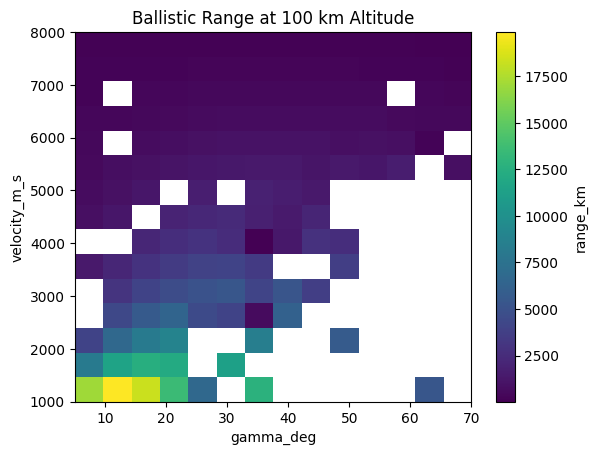

In [52]:
fig, ax = plt.subplots()
img = ax.imshow(df2.values, extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()), aspect="auto")
ax.set_xlabel("gamma_deg")
ax.set_ylabel("velocity_m_s")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("range_km")
ax.set_title(f"Ballistic Range at {selected_altitude} km Altitude")
plt.show()